[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/skarma91/logicmojo-ai-july-2026/blob/main/modules/module-3-nlp-to-transformers/02-attention/code/attention.ipynb)

# Class 3.2: Attention

The slides decode the formula. Here you implement scaled dot-product attention in NumPy on a tiny sentence and plot the attention weights, so you can see which token attends to which.

What we will cover:
- scaled dot-product attention, step by step
- softmax over scores into attention weights
- the context vector as a weighted blend
- an attention heatmap: the pronoun "it" attends to "cat"


## A tiny sentence, hand-built embeddings

We give each token a 4-number vector by hand. "cat" and "it" share features on purpose, so "it" should attend to "cat".

In [1]:
import numpy as np

tokens = ["the", "cat", "chased", "it"]
E = np.array([
    [1., 0., 0., 0.0],   # the
    [0., 1., 1., 0.0],   # cat     (animal features)
    [0., 0., 0., 1.0],   # chased
    [0., 1., 1., 0.2],   # it      (same animal features: refers to cat)
])
print("embedding matrix shape:", E.shape)

embedding matrix shape: (4, 4)


## Project to Q, K, V

In a real attention layer, Q, K, and V come from three learned weight matrices. Here we use the identity so the demo stays readable (the embeddings pass straight through); in practice these matrices are trained.

In [2]:
W_Q = np.eye(E.shape[1])     # learned in practice; identity keeps this demo transparent
W_K = np.eye(E.shape[1])
W_V = np.eye(E.shape[1])

Q = E @ W_Q
K = E @ W_K
V = E @ W_V
print("Q, K, V shapes:", Q.shape, K.shape, V.shape)

Q, K, V shapes: (4, 4) (4, 4) (4, 4)


## Scaled dot-product attention

Self-attention here uses the embeddings directly as Q, K, and V. Score every token against every token, scale, softmax each row, then blend the values.

In [3]:
d_k = Q.shape[1]
scores = Q @ K.T / np.sqrt(d_k)            # Q K^T / sqrt(d_k)

def softmax_rows(x):
    e = np.exp(x - x.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

A = softmax_rows(scores)                    # attention weights, each row sums to 1
context = A @ V                             # weighted blend of values

print("attention weights (rounded):")
print(np.round(A, 2))
print("row sums:", np.round(A.sum(axis=1), 2))

attention weights (rounded):
[[0.35 0.22 0.22 0.22]
 [0.13 0.37 0.13 0.37]
 [0.21 0.21 0.35 0.23]
 [0.13 0.36 0.15 0.37]]
row sums: [1. 1. 1. 1.]


## Which token does "it" attend to?

Read the row for "it". The largest weights should fall on "cat" (and itself), because they share features.

In [4]:
it_row = A[tokens.index("it")]
for tok, w in zip(tokens, it_row):
    print(f"  it -> {tok:7s}: {w:.2f}")
print("most-attended (besides itself):", tokens[int(np.argsort(it_row)[-2])])

  it -> the    : 0.13
  it -> cat    : 0.36
  it -> chased : 0.15
  it -> it     : 0.37
most-attended (besides itself): cat


## The attention heatmap

Rows are queries, columns are keys; brighter means more attention. The bright cell linking "it" and "cat" is co-reference, made visible.

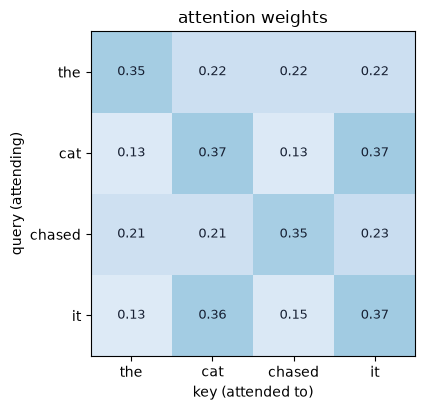

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(4.6, 4.2))
im = ax.imshow(A, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(tokens))); ax.set_xticklabels(tokens)
ax.set_yticks(range(len(tokens))); ax.set_yticklabels(tokens)
ax.set_xlabel("key (attended to)"); ax.set_ylabel("query (attending)")
for i in range(len(tokens)):
    for j in range(len(tokens)):
        ax.text(j, i, f"{A[i,j]:.2f}", ha="center", va="center",
                color="white" if A[i,j] > 0.5 else "#172033", fontsize=9)
plt.title("attention weights"); plt.tight_layout(); plt.show()

## Causal masking: no peeking ahead

For left-to-right generation, block each token from attending to later tokens. Add negative infinity to the future positions before the softmax, and the weights become lower-triangular.

In [6]:
n = len(tokens)
mask = np.triu(np.full((n, n), -np.inf), k=1)   # upper triangle (future) -> -inf
A_causal = softmax_rows(scores + mask)

print("causal attention weights:")
print(np.round(A_causal, 2))
print("row 0 attends only to itself:", np.round(A_causal[0], 2))

causal attention weights:
[[1.   0.   0.   0.  ]
 [0.27 0.73 0.   0.  ]
 [0.27 0.27 0.45 0.  ]
 [0.13 0.36 0.15 0.37]]
row 0 attends only to itself: [1. 0. 0. 0.]


## Your turn

**Micro-assignment.** Six problems on the attention math; see `../micro-assignment/README.md`.

**Next, class 3.3 (The Transformer):** wrap attention with multi-head, positional encoding, a feed-forward layer, and residuals into the full block.